# RandomForest

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import joblib
import optuna

import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\arnau.metaute\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 42

In [13]:
# dataset = pd.read_csv("./datasets/thyroid0387_cleanded.data", sep = ";", index_col="Unnamed: 0")
dataset = pd.read_csv("./datasets/thyroid0387_imputed.data", sep = ";", index_col="Unnamed: 0")

In [14]:
dataset.head()

,age,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,...,TT4_value,T4U_value,FTI_value,TBG_value,ref_STMW,ref_SVHC,ref_SVHD,ref_SVI,ref_WEST,ref_other
0,29.0,False,False,False,False,False,False,False,True,False,...,105.957986,0.964407,110.901257,32.308245,False,False,False,False,False,True
1,29.0,False,False,False,False,False,False,False,False,False,...,128.000000,0.972645,133.325191,21.728779,False,False,False,False,False,True
2,41.0,False,False,False,False,False,False,False,False,True,...,88.973106,0.776130,122.989623,11.000000,False,False,False,False,False,True
3,36.0,False,False,False,False,False,False,False,False,False,...,107.249494,1.015283,107.444888,26.000000,False,False,False,False,False,True
4,32.0,False,False,False,False,False,False,False,False,False,...,91.262932,0.818433,120.404426,36.000000,False,False,False,False,False,True


In [15]:
dataset["diagnosis_group"].value_counts()

diagnosis_group
normal                   6446
hypothyroid               572
general_health            435
replacement_therapy       336
binding_protein           324
misc                      221
hyperthyroid              184
antithyroid_treatment      33
Name: count, dtype: int64

In [16]:
label = LabelEncoder()
dataset["diagnosis_group"] = label.fit_transform(dataset["diagnosis_group"])

print(f"{dict(enumerate(label.classes_))}")

{0: 'antithyroid_treatment', 1: 'binding_protein', 2: 'general_health', 3: 'hyperthyroid', 4: 'hypothyroid', 5: 'misc', 6: 'normal', 7: 'replacement_therapy'}


In [17]:
x = dataset.drop(columns=["diagnosis_group", "diagnosis"])
y = dataset["diagnosis_group"]

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = seed)

In [19]:
print(f"X train: {x_train.shape}\nX test: {x_test.shape}\nY train: {y_train.shape}\nY test: {y_test.shape}")

X train: (5985, 28)
X test: (2566, 28)
Y train: (5985,)
Y test: (2566,)


## Model

In [20]:
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

## Model evaluation

Accuracy: 0.9879189399844115
F1 score: 0.987648935054203


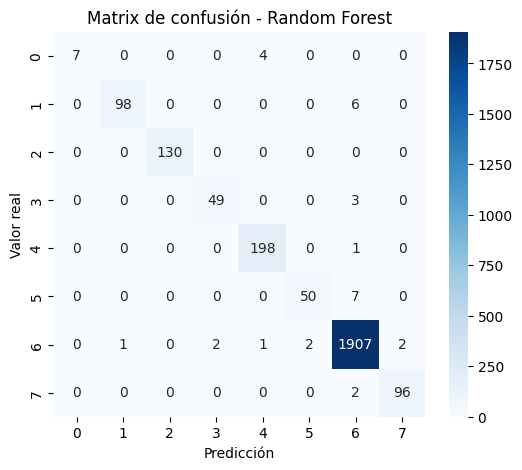

In [21]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matrix de confusión - Random Forest')
plt.show()


## Saving model

In [22]:
joblib.dump(rfc, "./models_saved/randforest.json")

['./models_saved/randforest.json']

## Bayesian optimization

Function that will be used during the optimization

In [23]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 15),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),

        "random_state": seed,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    return f1_score(y_test, y_pred, average = "weighted")

Optimization process

In [24]:
optimization = optuna.create_study(direction = "maximize")
optimization.optimize(objective, n_trials = 100)

[I 2025-04-15 20:30:37,414] A new study created in memory with name: no-name-b0ea53e0-ebe7-4d3f-bd9b-c95c41b0dcaa
[I 2025-04-15 20:30:38,549] Trial 0 finished with value: 0.9827428724556367 and parameters: {'n_estimators': 493, 'max_depth': 9, 'min_samples_split': 15, 'max_features': None}. Best is trial 0 with value: 0.9827428724556367.
[I 2025-04-15 20:30:39,078] Trial 1 finished with value: 0.892729880199339 and parameters: {'n_estimators': 418, 'max_depth': 4, 'min_samples_split': 13, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9827428724556367.
[I 2025-04-15 20:30:39,254] Trial 2 finished with value: 0.7517737440924855 and parameters: {'n_estimators': 132, 'max_depth': 3, 'min_samples_split': 8, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9827428724556367.
[I 2025-04-15 20:30:40,144] Trial 3 finished with value: 0.9855045989666308 and parameters: {'n_estimators': 425, 'max_depth': 19, 'min_samples_split': 10, 'max_features': None}. Best is trial 3 with value:

In [25]:
print(f"Best parameters: {optimization.best_params}")

Best parameters: {'n_estimators': 206, 'max_depth': 17, 'min_samples_split': 3, 'max_features': None}


In [26]:
rfc = RandomForestClassifier(**optimization.best_params)
rfc.fit(x_train, y_train)

y_pred = rfc.predict(x_test)

In [27]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred, average = 'weighted')}")

Accuracy: 0.9886983632112237
F1 score: 0.9886749936318535


In [28]:
joblib.dump(rfc, "./models_saved/randforest_opt.json")

['./models_saved/randforest_opt.json']